In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cooler
import cooltools
import bioframe
import cooltools.api.saddle as saddle_api  # 里面有 saddleplot 函数
from cooltools.lib.common import make_cooler_view

In [2]:
from collections import OrderedDict
# 1. 读 cooler
cool_path = "out_5kb.cool"
clr = cooler.Cooler(cool_path)
print("cooler chromnames:", clr.chromnames)
print("cooler chromsizes:", clr.chromsizes)

# 2. 读 fasta
fasta = bioframe.load_fasta("H37Rv.fna")   # 里面 key 是 'AL123456.3'，你已经看到了
print("fasta keys:", fasta.keys())

# 3. 重建一个 key 与 cooler 一致的字典
#    假设 fasta 里只有一个 key：'AL123456.3'
genome = OrderedDict()
genome["Chromosome"] = fasta["AL123456.3"]   # 把序列挂到名为 'Chromosome' 的 key 上

# 4. 用 cooler 自己的 bins 来算 GC，保证 bin 完全对齐
bins = clr.bins()[:][["chrom", "start", "end"]]   # chrom 是 'Chromosome'

gc_cov = bioframe.frac_gc(bins, genome)

# 5. 构造 phasing track：chrom, start, end, value(=GC)
gc_track = gc_cov[["chrom", "start", "end", "GC"]].copy()

print(gc_track.head())
print("track bin width:", (gc_track["end"] - gc_track["start"]).unique())
print("chrom in track:", gc_track["chrom"].unique())
print("chrom in cooler:", clr.chromnames)

# 6. 构造 view_df（用官方工具最省心）
view_df = make_cooler_view(clr)

# 7. 调 eigenvector
cis_eigs = cooltools.eigs_cis(
    clr,
    gc_track,
    view_df=view_df,
    n_eigs=3,
    # clr_weight_name='weight',  # 如果你的权重列不是 weight，请改这里
)

eigvec_table = cis_eigs[1][["chrom", "start", "end", "E1"]]
cvd = cooltools.expected_cis(clr=clr,view_df=view_df)
print(eigvec_table.head())

cooler chromnames: ['Chromosome']
cooler chromsizes: name
Chromosome    4411532
Name: length, dtype: int32
fasta keys: odict_keys(['AL123456.3'])
        chrom  start    end      GC
0  Chromosome      0   5000  0.6010
1  Chromosome   5000  10000  0.6248
2  Chromosome  10000  15000  0.6370
3  Chromosome  15000  20000  0.6504
4  Chromosome  20000  25000  0.6582
track bin width: [5000 1532]
chrom in track: ['Chromosome']
Categories (1, object): ['Chromosome']
chrom in cooler: ['Chromosome']


        chrom  start    end        E1
0  Chromosome      0   5000  0.062899
1  Chromosome   5000  10000  0.096332
2  Chromosome  10000  15000  0.218779
3  Chromosome  15000  20000  0.184154
4  Chromosome  20000  25000  0.234510


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cooler
import cooltools
import bioframe
import cooltools.api.saddle as saddle_api

from collections import OrderedDict
from cooltools.lib.common import make_cooler_view

# ……前面的 clr、genome、gc_track、eigs 都保持你现在的写法……

view_df = make_cooler_view(clr)

cis_eigs = cooltools.eigs_cis(
    clr,
    gc_track,
    view_df=view_df,
    n_eigs=3,
)
eigenvector_track = cis_eigs[1][['chrom','start','end','E1']]

cvd = cooltools.expected_cis(clr=clr, view_df=view_df)

In [4]:
import warnings
from cytoolz import merge

def saddleplot(
    track,
    saddledata,
    n_bins,
    vrange=None,
    qrange=(0.0, 1.0),
    cmap="coolwarm",
    scale="log",
    vmin=0.5,
    vmax=2,
    color=None,
    title=None,
    xlabel=None,
    ylabel=None,
    clabel=None,
    fig=None,
    fig_kws=None,
    heatmap_kws=None,
    margin_kws=None,
    cbar_kws=None,
    subplot_spec=None,
):
    """
    Generate a saddle plot.
    Parameters
    ----------
    track : pd.DataFrame
        See cooltools.digitize() for details.
    saddledata : 2D array-like
        Saddle matrix produced by `make_saddle`. It will include 2 flanking
        rows/columns for outlier signal values, thus the shape should be
        `(n+2, n+2)`.
    cmap : str or matplotlib colormap
        Colormap to use for plotting the saddle heatmap
    scale : str
        Color scaling to use for plotting the saddle heatmap: log or linear
    vmin, vmax : float
        Value limits for coloring the saddle heatmap
    color : matplotlib color value
        Face color for margin bar plots
    fig : matplotlib Figure, optional
        Specified figure to plot on. A new figure is created if none is
        provided.
    fig_kws : dict, optional
        Passed on to `plt.Figure()`
    heatmap_kws : dict, optional
        Passed on to `ax.imshow()`
    margin_kws : dict, optional
        Passed on to `ax.bar()` and `ax.barh()`
    cbar_kws : dict, optional
        Passed on to `plt.colorbar()`
    subplot_spec : GridSpec object
        Specify a subregion of a figure to using a GridSpec.
    Returns
    -------
    Dictionary of axes objects.
    """

#     warnings.warn(
#         "Generating a saddleplot will be deprecated in future versions, "
#         + "please see https://github.com/open2c_examples for examples on how to plot saddles.",
#         DeprecationWarning,
#     )

    from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
    from matplotlib.colors import Normalize, LogNorm
    from matplotlib import ticker
    import matplotlib.pyplot as plt

    class MinOneMaxFormatter(ticker.LogFormatter):
        def set_locs(self, locs=None):
            self._sublabels = set([vmin % 10 * 10, vmax % 10, 1])

        def __call__(self, x, pos=None):
            if x not in [vmin, 1, vmax]:
                return ""
            else:
                return "{x:g}".format(x=x)

    track_value_col = track.columns[3]
    track_values = track[track_value_col].values

    digitized_track, binedges = cooltools.digitize(
        track, n_bins, vrange=vrange, qrange=qrange
    )
    x = digitized_track[digitized_track.columns[3]].values.astype(int).copy()
    x = x[(x > -1) & (x < len(binedges) + 1)]

    # Old version
    # hist = np.bincount(x, minlength=len(binedges) + 1)

    groupmean = track[track.columns[3]].groupby(digitized_track[digitized_track.columns[3]]).mean()

    if qrange is not None:
        lo, hi = qrange
        binedges = np.linspace(lo, hi, n_bins + 1)

    # Barplot of mean values and saddledata are flanked by outlier bins
    n = saddledata.shape[0]
    X, Y = np.meshgrid(binedges, binedges)
    C = saddledata
    if (n - n_bins) == 2:
        C = C[1:-1, 1:-1]
        groupmean = groupmean[1:-1]

    # Layout
    if subplot_spec is not None:
        GridSpec = partial(GridSpecFromSubplotSpec, subplot_spec=subplot_spec)
    grid = {}
    gs = GridSpec(
        nrows=3,
        ncols=3,
        width_ratios=[0.2, 1, 0.1],
        height_ratios=[0.2, 1, 0.1],
        wspace=0.05,
        hspace=0.05,
    )

    # Figure
    if fig is None:
        fig_kws_default = dict(figsize=(5, 5))
        fig_kws = merge(fig_kws_default, fig_kws if fig_kws is not None else {})
        fig = plt.figure(**fig_kws)

    # Heatmap
    if scale == "log":
        norm = LogNorm(vmin=vmin, vmax=vmax)
    elif scale == "linear":
        norm = Normalize(vmin=vmin, vmax=vmax)
    else:
        raise ValueError("Only linear and log color scaling is supported")

    grid["ax_heatmap"] = ax = plt.subplot(gs[4])
    heatmap_kws_default = dict(cmap="coolwarm", rasterized=True)
    heatmap_kws = merge(
        heatmap_kws_default, heatmap_kws if heatmap_kws is not None else {}
    )
    img = ax.pcolormesh(X, Y, C, norm=norm, **heatmap_kws)
    plt.gca().yaxis.set_visible(False)

    # Margins
    margin_kws_default = dict(edgecolor="k", facecolor=color, linewidth=1)
    margin_kws = merge(margin_kws_default, margin_kws if margin_kws is not None else {})
    # left margin hist
    grid["ax_margin_y"] = plt.subplot(gs[3], sharey=grid["ax_heatmap"])

    plt.barh(
        binedges, height=1/len(binedges), width=groupmean, align="edge", **margin_kws
    )

    plt.xlim(plt.xlim()[1], plt.xlim()[0])  # fliplr
    plt.ylim(hi, lo)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["bottom"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    plt.gca().xaxis.set_visible(False)
    # top margin hist
    grid["ax_margin_x"] = plt.subplot(gs[1], sharex=grid["ax_heatmap"])

    plt.bar(
        binedges, width=1/len(binedges), height=groupmean, align="edge", **margin_kws
    )

    plt.xlim(lo, hi)
    # plt.ylim(plt.ylim())  # correct
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    plt.gca().xaxis.set_visible(False)
    plt.gca().yaxis.set_visible(False)

#     # Colorbar
    grid["ax_cbar"] = plt.subplot(gs[5])
    cbar_kws_default = dict(fraction=0.8, label=clabel or "")
    cbar_kws = merge(cbar_kws_default, cbar_kws if cbar_kws is not None else {})
    if scale == "linear" and vmin is not None and vmax is not None:
        grid["ax_cbar"] = cb = plt.colorbar(img, **cbar_kws)
        # cb.set_ticks(np.arange(vmin, vmax + 0.001, 0.5))
        # # do linspace between vmin and vmax of 5 segments and trunc to 1 decimal:
        decimal = 10
        nsegments = 5
        cd_ticks = np.trunc(np.linspace(vmin, vmax, nsegments) * decimal) / decimal
        cb.set_ticks(cd_ticks)
    else:
        print('cbar')

        cb = plt.colorbar(img, format=MinOneMaxFormatter(), cax=grid["ax_cbar"], **cbar_kws)
        cb.ax.yaxis.set_minor_formatter(MinOneMaxFormatter())

    # extra settings
    grid["ax_heatmap"].set_xlim(lo, hi)
    grid["ax_heatmap"].set_ylim(hi, lo)
    grid['ax_heatmap'].grid(False)
    if title is not None:
        grid["ax_margin_x"].set_title(title)
    if xlabel is not None:
        grid["ax_heatmap"].set_xlabel(xlabel)
    if ylabel is not None:
        grid["ax_margin_y"].set_ylabel(ylabel)
    plt.savefig('test1.pdf')

    return grid

cbar


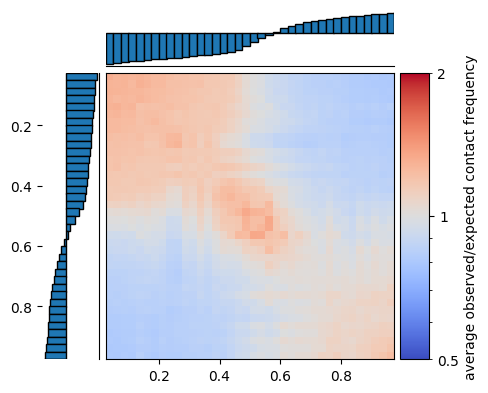

In [5]:
Q_LO = 0.025 # ignore 2.5% of genomic bins with the lowest E1 values
Q_HI = 0.975 # ignore 2.5% of genomic bins with the highest E1 values
N_GROUPS = 38 # divide remaining 95% of the genome into 38 equisized groups, 2.5% each
cvd = cooltools.expected_cis(
        clr=clr,
        view_df=view_df,
)
interaction_sum, interaction_count =  cooltools.saddle(
        clr,
        cvd,
        eigenvector_track,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df
)
saddleplot(eigenvector_track,
           interaction_sum/interaction_count,
           N_GROUPS,
           qrange=(Q_LO,Q_HI),
           cbar_kws={'label':'average observed/expected contact frequency'}
          );
plt.savefig('kolatentAB.pdf')

In [7]:
Q_LO = 0.025 # ignore 2.5% of genomic bins with the lowest E1 values
Q_HI = 0.975 # ignore 2.5% of genomic bins with the highest E1 values
N_GROUPS = 38 # divide remaining 95% of the genome into 38 equisized groups, 2.5% each

       group  cs_log_point  cs_log_mean  cs_log_ci_low  cs_log_ci_high  \
0         WT     29.162212    29.152558      28.853547       29.423171   
1    Hypoxia      9.805754     9.823737       9.166901       10.588694   
2     Latent     14.418083    14.504874      13.413638       15.943165   
3     napmKO     19.044480    20.201927      17.170772       27.950657   
4  kohypoxia      4.374131     4.374382       3.894135        4.882163   

       muAA      muBB      muAB  
0  4.219403  4.383254  0.000001  
1  2.320199  2.256907  0.016990  
2  2.172062  2.189880  0.001613  
3  2.164700  2.268295  0.000161  
4  1.913872  1.433655  0.185929  
WT vs Hypoxia: p=1.000e-04
WT vs Latent: p=1.000e-04
WT vs napmKO: p=1.000e-04
napmKO vs kohypoxia: p=1.000e-04


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 46 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'H', 'I', 'K', 'L', 'O', 'S', 'T', 'W', 'a', 'b', 'comma', 'e', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'less', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'percent', 'r', 's', 'slash', 'space', 't', 'three', 'two', 'x', 'y', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 8, 11, 12, 15, 16, 18, 19, 20, 21, 22, 23, 24, 28, 31, 36, 37, 38, 43, 44, 46, 47, 50, 54, 55, 58, 68, 69, 72, 74, 75, 76, 78, 79, 80, 81, 82, 83, 85, 86,

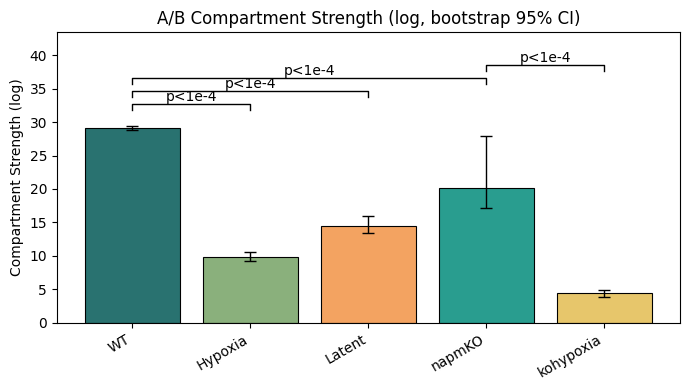

In [3]:
import seaborn as sns

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'
from collections import OrderedDict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cooler
import bioframe
import cooltools
from cooltools.lib.common import make_cooler_view


# -----------------------------
# 0) Helper functions
# -----------------------------
def extract_saddle_blocks(M, frac=0.2, drop_zeros=False):
    """
    Extract AA/BB/AB pixel vectors from saddle matrix M.
    For sparse data, keep zeros (drop_zeros=False) and use eps later.
    """
    M = np.asarray(M, dtype=float)
    n = M.shape[0]
    k = max(1, int(round(n * frac)))

    BB = M[:k, :k].ravel()          # top-left
    AA = M[-k:, -k:].ravel()        # bottom-right
    AB1 = M[:k, -k:].ravel()        # top-right
    AB2 = M[-k:, :k].ravel()        # bottom-left
    AB = np.concatenate([AB1, AB2])

    # drop NaN
    AA = AA[~np.isnan(AA)]
    BB = BB[~np.isnan(BB)]
    AB = AB[~np.isnan(AB)]

    if drop_zeros:
        AA = AA[AA != 0]
        BB = BB[BB != 0]
        AB = AB[AB != 0]

    return AA, BB, AB


def log_strength(muAA, muBB, muAB, eps=1e-6):
    """
    Flyamer/FAN-C compartment strength:
    CS_log = ln( AA * BB / AB^2 )
    """
    return np.log((muAA * muBB + eps) / ((muAB + eps) ** 2))


def bootstrap_log_strength(AA, BB, AB, n_boot=10000, seed=42, eps=1e-6):
    """
    Bootstrap CS_log by resampling pixel values in AA/BB/AB blocks.
    Return point estimate, (95% CI), bootstrap samples
    """
    rng = np.random.default_rng(seed)

    if len(AA) == 0 or len(BB) == 0 or len(AB) == 0:
        raise ValueError(f"Empty block: nAA={len(AA)}, nBB={len(BB)}, nAB={len(AB)}")

    # keep zeros but avoid muAB==0
    AB = np.asarray(AB, dtype=float)
    AB = np.where(AB == 0, eps, AB)

    nAA, nBB, nAB = len(AA), len(BB), len(AB)

    idxAA = rng.integers(0, nAA, size=(n_boot, nAA))
    idxBB = rng.integers(0, nBB, size=(n_boot, nBB))
    idxAB = rng.integers(0, nAB, size=(n_boot, nAB))

    muAA = AA[idxAA].mean(axis=1)
    muBB = BB[idxBB].mean(axis=1)
    muAB = AB[idxAB].mean(axis=1)

    cs_boot = np.log((muAA * muBB + eps) / ((muAB + eps) ** 2))

    cs_mean = cs_boot.mean()
    cs_lo, cs_hi = np.percentile(cs_boot, [2.5, 97.5])

    return cs_mean, (cs_lo, cs_hi), cs_boot


def bootstrap_pvalue(cs_boot_a, cs_boot_b):
    """
    Two-sided bootstrap p-value for delta = a - b
    """
    n = min(len(cs_boot_a), len(cs_boot_b))
    a = cs_boot_a[:n]
    b = cs_boot_b[:n]
    delta = a - b
    p_left = np.mean(delta <= 0)
    p_right = np.mean(delta >= 0)
    p = 2 * min(p_left, p_right)
    return max(p, 1.0 / n)


def p_to_stars(p):
    if p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


def add_sig_bar(ax, x1, x2, y, h, text, lw=1):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], linewidth=lw, color="black")
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom")


# -----------------------------
# 1) Compute log CS for one cool
# -----------------------------
def compute_cslog_one_cool(
    cool_path,
    fasta_path="H37Rv.fna",
    cooler_chrom_name="Chromosome",
    fasta_key="AL123456.3",
    n_bins=20,
    frac=0.2,
    qrange=(0.02, 0.98),
    min_diag=2,
    target_bp=500_000,
    expected_value_col="balanced.avg.smoothed.agg",
    n_boot=10000,
    seed=42,
    eps=1e-6,
):
    clr = cooler.Cooler(cool_path)
    binsize = clr.binsize

    max_diag = int(target_bp / binsize)
    max_diag = max(max_diag, min_diag + 1)

    fasta = bioframe.load_fasta(fasta_path)
    genome = OrderedDict()
    genome[cooler_chrom_name] = fasta[fasta_key]

    bins = clr.bins()[:][["chrom", "start", "end"]]
    gc_cov = bioframe.frac_gc(bins, genome)
    gc_track = gc_cov[["chrom", "start", "end", "GC"]].copy()

    view_df = make_cooler_view(clr)

    eigvals, eig_df = cooltools.eigs_cis(
        clr,
        gc_track,
        view_df=view_df,
        n_eigs=3,
    )

    eig_col = "E1" if "E1" in eig_df.columns else ("eig1" if "eig1" in eig_df.columns else None)
    if eig_col is None:
        raise ValueError(f"Cannot find E1/eig1 in eig_df columns: {eig_df.columns.tolist()}")

    track = eig_df[["chrom", "start", "end", eig_col]].copy()

    expected = cooltools.expected_cis(clr=clr, view_df=view_df)
    if expected_value_col not in expected.columns:
        raise ValueError(
            f"expected_value_col={expected_value_col} not found. "
            f"Available: {expected.columns.tolist()}"
        )

    saddle = cooltools.saddle(
        clr,
        expected,
        track,
        "cis",
        expected_value_col=expected_value_col,
        n_bins=n_bins,
        qrange=qrange,
        view_df=view_df,
        min_diag=min_diag,
        max_diag=max_diag,
    )

    # your version returns (matrix, binedges)
    M_raw = saddle[0]

    # normalize to background ~ 1 (median)
    M_norm = M_raw / np.nanmedian(M_raw)

    # extract AA/BB/AB pixels
    AA, BB, AB = extract_saddle_blocks(M_norm, frac=frac, drop_zeros=False)

    # point estimate using means
    muAA = np.nanmean(AA)
    muBB = np.nanmean(BB)
    muAB = np.nanmean(np.where(AB == 0, eps, AB))
    cs_log_point = log_strength(muAA, muBB, muAB, eps=eps)

    # bootstrap CI
    cs_log_mean, (cs_log_lo, cs_log_hi), cs_log_boot = bootstrap_log_strength(
        AA, BB, AB, n_boot=n_boot, seed=seed, eps=eps
    )

    return {
        "sample": cool_path,
        "binsize": binsize,
        "target_bp": target_bp,
        "min_diag": min_diag,
        "max_diag_bins": max_diag,
        "n_bins": n_bins,
        "frac": frac,
        "qrange": qrange,
        "eig_col": eig_col,
        "expected_value_col": expected_value_col,
        "muAA": muAA,
        "muBB": muBB,
        "muAB": muAB,
        "cs_log_point": cs_log_point,
        "cs_log_mean": cs_log_mean,
        "cs_log_ci_low": cs_log_lo,
        "cs_log_ci_high": cs_log_hi,
        "cs_log_boot": cs_log_boot,
        "Mmin": np.nanmin(M_norm),
        "Mmed": np.nanmedian(M_norm),
        "Mmax": np.nanmax(M_norm),
    }


# -----------------------------
# 2) Run on your 5 cool files
# -----------------------------
cool_files = {
    "WT": "wt_5k.cool::/resolutions/5000",
    "Hypoxia": "hypoxia_5k.mcool::/resolutions/5000",
    "Latent": "latent_5k.mcool::/resolutions/5000",
    "napmKO": "napm_ko_5k.cool::/resolutions/5000",
    "kohypoxia": "napmhypoxia_5k.mcool::/resolutions/5000",
}

PARAMS = dict(
    fasta_path="H37Rv.fna",
    cooler_chrom_name="Chromosome",
    fasta_key="AL123456.3",
    n_bins=20,
    frac=0.2,
    qrange=(0.02, 0.98),
    min_diag=2,
    target_bp=500_000,
    expected_value_col="balanced.avg.smoothed.agg",
    n_boot=10000,
    seed=42,
    eps=1e-6,
)

rows = []
for group, path in cool_files.items():
    res = compute_cslog_one_cool(path, **PARAMS)
    res["group"] = group
    rows.append(res)

df = pd.DataFrame(rows)
df = df.set_index("group").loc[list(cool_files.keys())].reset_index()

print(df[["group", "cs_log_point", "cs_log_mean", "cs_log_ci_low", "cs_log_ci_high", "muAA", "muBB", "muAB"]])


# -----------------------------
# 3) Significance (standard: WT vs others + napmKO vs kohypoxia)
# -----------------------------
boot = {g: df.loc[df["group"] == g, "cs_log_boot"].values[0] for g in df["group"]}

comparisons = [
    ("WT", "Hypoxia"),
    ("WT", "Latent"),
    ("WT", "napmKO"),
    ("napmKO", "kohypoxia"),
]

comp_results = []
for a, b in comparisons:
    p = bootstrap_pvalue(boot[b], boot[a])   # compare b vs a
    comp_results.append((a, b, p))
    print(f"{a} vs {b}: p={p:.3e}")


# -----------------------------
# 4) Plot bar chart + 95% CI + selected significance bars (label p values)
# -----------------------------
y = df["cs_log_mean"].values
yerr_low = y - df["cs_log_ci_low"].values
yerr_high = df["cs_log_ci_high"].values - y
yerr = np.vstack([yerr_low, yerr_high])

x = np.arange(len(df))

# ① 自定义每组柱子的颜色（你可以按需改）
color_map = {
    "WT": '#297270',
    "Hypoxia": '#8ab07c',
    "Latent": '#f3a361',
    "napmKO": '#299d8f',
    "kohypoxia": '#e7c66b',
}
bar_colors = [color_map.get(g, "#999999") for g in df["group"]]

fig, ax = plt.subplots(figsize=(7, 4))

# ② 设置柱子颜色；同时给边框让视觉更清晰
ax.bar(x, y, color=bar_colors, edgecolor="black", linewidth=0.8)

ax.errorbar(x, y, yerr=yerr, fmt="none", capsize=4, ecolor="black", elinewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(df["group"], rotation=30, ha="right")
ax.set_ylabel("Compartment Strength (log)")
ax.set_title("A/B Compartment Strength (log, bootstrap 95% CI)")

idx = {g: i for i, g in enumerate(df["group"])}

# base height above the tallest bar
y_top = np.max(y + yerr_high)
pad = 0.08 * y_top
h = 0.03 * y_top

# ③ p 值显示格式：小于 1e-4 用科学计数法，否则用小数
def format_p(p):
    return f"p={p:.2e}" if p < 1e-4 else f"p<1e-4"

# draw significance bars with increasing height to avoid overlap
for j, (a, b, p) in enumerate(comp_results):
    x1, x2 = idx[a], idx[b]
    y_line = y_top + pad + j * 2.2 * h
    add_sig_bar(ax, x1, x2, y_line, h, format_p(p))

# make room for the highest sig bar
ax.set_ylim(0, y_top + pad + (len(comp_results) + 2) * 2.2 * h)

fig.tight_layout()
fig.savefig("cs_log_with_ci_pvalues_colored.pdf", dpi=300)
plt.show()